# Entretien technique Oplit — Atelier & temps de production

**Le contexte.** Oplit aide des usines à **ordonnancer leur production**. Un nouveau client (un atelier d'usinage / soudure / assemblage) veut qu'on l'aide à planifier ses opérations. On va partir de *son* problème, pas du code.

## Partie A — Ordonnancement de l'atelier (flow shop)

L'atelier fabrique 3 types de pièces (A, B, C) sur **2 machines**. Chaque pièce passe sur la Machine 1 **puis** la Machine 2 (dans cet ordre). Une machine ne traite qu'une pièce à la fois.

Nous souhaitons produire une pièce de chaque type.

| Pièce | Machine 1 | Machine 2 |
|-------|-----------|-----------|
| A     | 2 h       | 3 h       |
| B     | 4 h       | 1 h       |
| C     | 3 h       | 2 h       |

Le responsable d'atelier dit : *« Je veux tout sortir le plus vite possible. »*

💬 **À discuter (pas de modèle mathématique attendu) :**
- Que cherche-t-on à optimiser, dans les mots du client puis dans les vôtres ?
- Qu'est-ce qu'on **décide** réellement ici ? Quelles **contraintes** ne peut-on pas violer ?
- Quelle **règle simple** (heuristique) un planificateur humain pourrait-il appliquer ? Pourquoi serait-elle raisonnable ?

## Partie B — Prédire les temps de traitement

Problème : tout ce qu'on vient de faire suppose qu'on **connaît** la durée de chaque opération (2 h, 4 h…). Dans le monde réel, la même opération prend un temps différent selon la pièce, la machine, la taille du lot, et même la situation de l'usine à l'instant t.

Le client n'a pas de temps standards propres — il a un **export brut de ce qui s'est réellement passé** sur l'atelier. Donc le problème d'ordonnancement dépend en silence d'un problème de **prédiction** : *combien de temps va durer cette opération ?*

⚠️ Subtilité : la **durée réelle n'est pas une colonne du fichier**. L'export ne contient que des **horodatages** (début / fin réels). À vous de reconstruire la cible.

Voici un échantillon de l'export client. **Réagissez à ce que vous voyez.**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Marche en local (repo cloné) ET sur Google Colab (téléchargement auto depuis GitHub)
LOCAL_PATH = "../data/operations_raw.csv"
RAW_URL = "https://raw.githubusercontent.com/alexandrerioo/scheduling_sandbox/main/data/operations_raw.csv"
CSV = LOCAL_PATH if os.path.exists(LOCAL_PATH) else RAW_URL

df = pd.read_csv(CSV, dtype=str)
print(f"{len(df):,} lignes  x  {df.shape[1]} colonnes")
df.head(10)

6,090 lignes  x  14 colonnes


,of_id,article_ref,article_family,diameter_mm,material,color,quantity,machine_id,machine_type,actual_start_ts,actual_end_ts,downtime_min,status,record_created_ts
0,OF-2024-00000,ART-F11,Finition,147.9,Acier,Gris,66,MCH-07,MANUAL,10/05/2024 21:18,10/05/2024 23:02,0.0,done,10/05/2024 23:06
1,OF-2024-00001,ART-A26,Assemblage,183.1,Inox,Rouge,63,MCH-10,ROBOT_CELL,2024-04-26 13:16:55,NaN,8.9,running,2024-04-26 15:03:26
2,OF-2024-00002,ART-F07,Finition,147.0,Acier,Gris,28,MCH-01,CNC_FAST,2024-07-26 08:24:11,2024-07-26 08:45:21,0.0,done,2024-07-26 08:49:06
3,OF-2024-00003,ART-U24,Usinage,173.0,Aluminium,Vert,193,MCH-02,CNC_FAST,2024-07-07 18:16:47,2024-07-07 22:16:33,48.0,done,2024-07-07 22:19:52
4,OF-2024-00004,ART-S25,Soudure,151.9,Acier,Bleu,67,MCH-07,MANUAL,08/04/2024 09:08,08/04/2024 15:39,58.1,done,08/04/2024 15:42
5,OF-2024-00005,ART-U28,Usinage,115.2,Aluminium,Bleu,36,MCH-04,CNC_STD,2024-06-29 08:18:03,2024-06-29 09:31:43,0.0,done,2024-06-29 09:34:31
6,OF-2024-00006,ART-U00,Usinage,184.0,Inox,Jaune,54,MCH-03,CNC_STD,2024-04-28 21:55:41,2024-04-29 00:26:00,0.0,done,2024-04-29 00:26:57
7,OF-2024-00007,ART-A26,Assemblage,183.1,Inox,Rouge,65,MCH-11,ROBOT_CELL,2024-07-24 20:06:41,2024-07-24 22:03:36,0.0,done,2024-07-24 22:06:57
8,OF-2024-00008,ART-U32,Usinage,131.7,Aluminium,Gris,64,MCH-05,CNC_STD,2024-01-22 21:28:13,2024-01-23 00:45:53,53.5,done,2024-01-23 00:49:19
9,OF-2024-00009,ART-F19,Finition,100.8,Aluminium,Gris,34,MCH-08,MANUAL,2024-04-10 07:02:55,2024-04-10 07:50:57,0.0,done,2024-04-10 07:52:38


### Glossaire des colonnes

| Colonne | Description |
|---|---|
| `of_id` | Ordre de Fabrication |
| `article_ref`, `article_family` | Référence article et famille (Usinage, Soudure, Assemblage, Finition) |
| `diameter_mm` | Diamètre de la pièce (mm) |
| `material` | Matière : Aluminium / Acier / Inox / Titane |
| `color` | Couleur de la pièce |
| `quantity` | Quantité de l'opération |
| `machine_id`, `machine_type` | Machine physique et son type |
| `actual_start_ts`, `actual_end_ts` | Début / fin réels de l'opération |
| `downtime_min` | Minutes d'arrêt machine pendant l'opération |
| `status` | done / running / aborted |
| `record_created_ts` | Horodatage d'écriture de la ligne par le MES |

In [2]:
# Volumétrie & période
# NB : les formats de date ne sont pas homogènes selon la source -> on parse les deux
iso = pd.to_datetime(df["actual_start_ts"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
fr  = pd.to_datetime(df["actual_start_ts"], format="%d/%m/%Y %H:%M", errors="coerce")
ts = iso.fillna(fr)
print("Période :", ts.min(), "->", ts.max())
print("OF distincts          :", df["of_id"].nunique())
print("Références article     :", df["article_ref"].nunique(), "(formes de surface)")
print("Matières / couleurs    :", df["material"].nunique(), "/", df["color"].nunique())
print("Machines / types       :", df["machine_id"].nunique(), "/", df["machine_type"].nunique())
print("actual_end_ts manquant :", (df["actual_end_ts"].fillna('') == '').sum(), "lignes")
print("Lignes dupliquées      :", df.duplicated().sum())

Période : 2024-01-01 06:06:00 -> 2024-08-31 22:08:35
OF distincts          : 6000
Références article     : 89 (formes de surface)
Matières / couleurs    : 4 / 6
Machines / types       : 12 / 4
actual_end_ts manquant : 244 lignes
Lignes dupliquées      : 62


### 📊 Trois visualisations pour amorcer la réflexion

#### 1. Observations par article

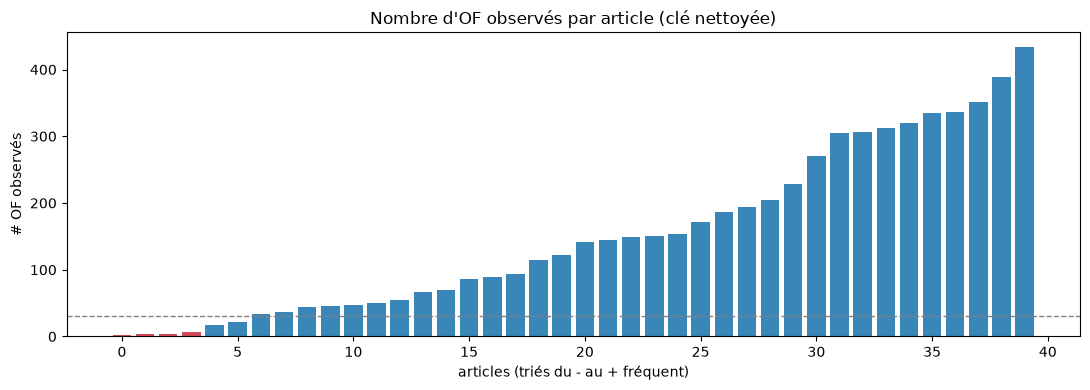

Articles distincts (nettoyés) : 40
Plus faibles volumétries       : [np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(17), np.int64(21)]


In [3]:
import matplotlib.pyplot as plt

# clé article "canonique" : on nettoie espaces / casse / tiret / suffixe parasite
canon = (df["article_ref"].str.strip().str.upper()
         .str.replace("-", "", regex=False).str.replace("MM", "", regex=False))
counts = canon.value_counts().sort_values()

plt.figure(figsize=(11, 4))
colors = ["#d1495b" if v <= 8 else "#3a86b8" for v in counts.values]
plt.bar(range(len(counts)), counts.values, color=colors)
plt.axhline(30, ls="--", lw=1, color="grey")
plt.title("Nombre d'OF observés par article (clé nettoyée)")
plt.xlabel("articles (triés du - au + fréquent)")
plt.ylabel("# OF observés")
plt.tight_layout(); plt.show()

print("Articles distincts (nettoyés) :", counts.size)
print("Plus faibles volumétries       :", sorted(counts.values)[:6])

#### 2. Distribution de la cible

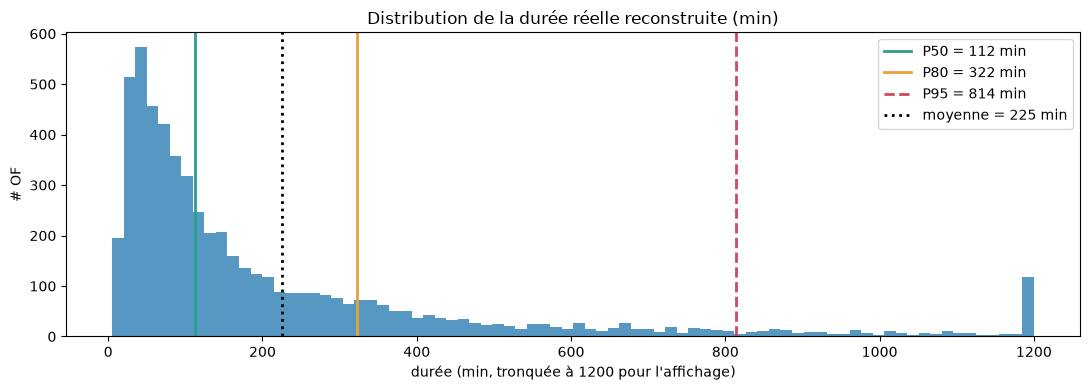

médiane=112 | moyenne=225 | P80=322 | P95=814  (min)


In [4]:
import numpy as np

def parse_ts(s):
    a = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S", errors="coerce")
    b = pd.to_datetime(s, format="%d/%m/%Y %H:%M", errors="coerce")
    return a.fillna(b)

# cible reconstruite = fin - début, en minutes (on retire les durées <= 0 et manquantes)
dur = (parse_ts(df["actual_end_ts"]) - parse_ts(df["actual_start_ts"])).dt.total_seconds() / 60
dur = dur[dur > 0]

plt.figure(figsize=(11, 4))
plt.hist(dur.clip(upper=1200), bins=80, color="#3a86b8", alpha=.85)
for p, c, ls in [(50, "#2a9d8f", "-"), (80, "#e9a23b", "-"), (95, "#d1495b", "--")]:
    v = np.percentile(dur, p)
    plt.axvline(v, color=c, ls=ls, lw=2, label=f"P{p} = {v:.0f} min")
plt.axvline(dur.mean(), color="black", ls=":", lw=2, label=f"moyenne = {dur.mean():.0f} min")
plt.title("Distribution de la durée réelle reconstruite (min)")
plt.xlabel("durée (min, tronquée à 1200 pour l'affichage)")
plt.ylabel("# OF")
plt.legend(); plt.tight_layout(); plt.show()

print(f"médiane={dur.median():.0f} | moyenne={dur.mean():.0f} | "
      f"P80={np.percentile(dur,80):.0f} | P95={np.percentile(dur,95):.0f}  (min)")

#### 3. `downtime_min` : une bonne feature ?

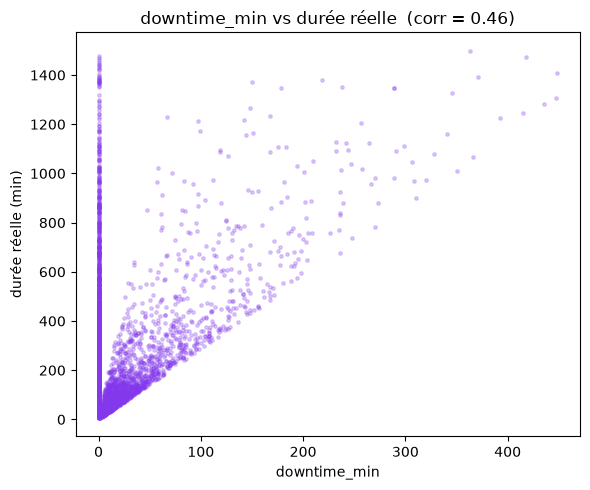

In [5]:
dt = pd.to_numeric(df["downtime_min"], errors="coerce")
dur_all = (parse_ts(df["actual_end_ts"]) - parse_ts(df["actual_start_ts"])).dt.total_seconds() / 60
m = dur_all.between(0.1, 1500) & dt.notna()

plt.figure(figsize=(6, 5))
plt.scatter(dt[m], dur_all[m], s=6, alpha=.25, color="#8338ec")
plt.title(f"downtime_min vs durée réelle  (corr = {dt[m].corr(dur_all[m]):.2f})")
plt.xlabel("downtime_min")
plt.ylabel("durée réelle (min)")
plt.tight_layout(); plt.show()

In [6]:
# Zone de travail libre
